In [1]:
import polars as pl
import matplotlib.pyplot as plt

In [2]:
data_jan_2009 = pl.read_parquet("C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi/yellow_tripdata_2009-01.parquet", 
                                columns=['Trip_Pickup_DateTime','Trip_Dropoff_DateTime','Passenger_Count','Trip_Distance',
                                         'Payment_Type','Fare_Amt','Tip_Amt'])

In [3]:
len(data_jan_2009)

14092413

In [4]:
data_jan_2009.head()

Trip_Pickup_DateTime,Trip_Dropoff_DateTime,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amt,Tip_Amt
str,str,i64,f64,str,f64,f64
"""2009-01-04 02:52:00""","""2009-01-04 03:02:00""",1,2.63,"""CASH""",8.9,0.0
"""2009-01-04 03:31:00""","""2009-01-04 03:38:00""",3,4.55,"""Credit""",12.1,2.0
"""2009-01-03 15:43:00""","""2009-01-03 15:57:00""",5,10.35,"""Credit""",23.7,4.74
"""2009-01-01 20:52:58""","""2009-01-01 21:14:00""",1,5.0,"""CREDIT""",14.9,3.05
"""2009-01-24 16:18:23""","""2009-01-24 16:24:56""",1,0.4,"""CASH""",3.7,0.0


In [5]:
data_jan_2009.columns

['Trip_Pickup_DateTime',
 'Trip_Dropoff_DateTime',
 'Passenger_Count',
 'Trip_Distance',
 'Payment_Type',
 'Fare_Amt',
 'Tip_Amt']

In [6]:
data_jan_2009 = data_jan_2009.rename({
    "Trip_Pickup_DateTime": "trip_pickup_dateTime",
    "Trip_Dropoff_DateTime": "trip_dropoff_dateTime",
    "Passenger_Count": "passenger_count",
    "Trip_Distance": "trip_distance",
    "Payment_Type": "payment_type",
    "Fare_Amt": "fare_amt",
    "Tip_Amt": "tip_amt"
})

In [7]:
data_jan_2009 = data_jan_2009.filter(
    (pl.col("passenger_count") >= 0) & (pl.col("trip_distance") >= 0) & (pl.col("trip_distance") <= 50) & 
    (pl.col("fare_amt") >= 0) & (pl.col("tip_amt") >= 0)
)
len(data_jan_2009)

14092413

In [8]:
mapping = {
    "Credit": 0,
    "CREDIT": 0,
    "CASH": 1,
    "Cash": 1,
    "No Charge": 2,
    "Dispute": 3
}

data_jan_2009 = data_jan_2009.with_columns(
    pl.col("payment_type").replace(mapping)
)

In [9]:
data_jan_2009.head()

trip_pickup_dateTime,trip_dropoff_dateTime,passenger_count,trip_distance,payment_type,fare_amt,tip_amt
str,str,i64,f64,str,f64,f64
"""2009-01-04 02:52:00""","""2009-01-04 03:02:00""",1,2.63,"""1""",8.9,0.0
"""2009-01-04 03:31:00""","""2009-01-04 03:38:00""",3,4.55,"""0""",12.1,2.0
"""2009-01-03 15:43:00""","""2009-01-03 15:57:00""",5,10.35,"""0""",23.7,4.74
"""2009-01-01 20:52:58""","""2009-01-01 21:14:00""",1,5.0,"""0""",14.9,3.05
"""2009-01-24 16:18:23""","""2009-01-24 16:24:56""",1,0.4,"""1""",3.7,0.0


In [10]:
data_jan_2009 = data_jan_2009.with_columns([
    pl.col("trip_pickup_dateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S"),
    pl.col("trip_dropoff_dateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S"),
    pl.col("payment_type").cast(pl.Int64)
])

In [11]:
data_jan_2009.head()

trip_pickup_dateTime,trip_dropoff_dateTime,passenger_count,trip_distance,payment_type,fare_amt,tip_amt
datetime[μs],datetime[μs],i64,f64,i64,f64,f64
2009-01-04 02:52:00,2009-01-04 03:02:00,1,2.63,1,8.9,0.0
2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,0,12.1,2.0
2009-01-03 15:43:00,2009-01-03 15:57:00,5,10.35,0,23.7,4.74
2009-01-01 20:52:58,2009-01-01 21:14:00,1,5.0,0,14.9,3.05
2009-01-24 16:18:23,2009-01-24 16:24:56,1,0.4,1,3.7,0.0


In [12]:
data_jan_2009 = data_jan_2009.with_columns(
    ((pl.col("trip_dropoff_dateTime") - pl.col("trip_pickup_dateTime")).dt.total_seconds() / 86400)
    .cast(pl.Int64)
    .alias("duration_days")
)

In [13]:
data_jan_2009.head()

trip_pickup_dateTime,trip_dropoff_dateTime,passenger_count,trip_distance,payment_type,fare_amt,tip_amt,duration_days
datetime[μs],datetime[μs],i64,f64,i64,f64,f64,i64
2009-01-04 02:52:00,2009-01-04 03:02:00,1,2.63,1,8.9,0.0,0
2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,0,12.1,2.0,0
2009-01-03 15:43:00,2009-01-03 15:57:00,5,10.35,0,23.7,4.74,0
2009-01-01 20:52:58,2009-01-01 21:14:00,1,5.0,0,14.9,3.05,0
2009-01-24 16:18:23,2009-01-24 16:24:56,1,0.4,1,3.7,0.0,0


In [14]:
data_jan_2009 = data_jan_2009.filter(
    (pl.col("duration_days") == 0) 
)
len(data_jan_2009)

14092358

In [15]:
data_jan_2009 = data_jan_2009.with_columns(
    ((pl.col("trip_dropoff_dateTime") - pl.col("trip_pickup_dateTime")).dt.total_seconds())
    .cast(pl.Int64)
    .alias("duration_seconds")
)

In [16]:
data_jan_2009.head()

trip_pickup_dateTime,trip_dropoff_dateTime,passenger_count,trip_distance,payment_type,fare_amt,tip_amt,duration_days,duration_seconds
datetime[μs],datetime[μs],i64,f64,i64,f64,f64,i64,i64
2009-01-04 02:52:00,2009-01-04 03:02:00,1,2.63,1,8.9,0.0,0,600
2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,0,12.1,2.0,0,420
2009-01-03 15:43:00,2009-01-03 15:57:00,5,10.35,0,23.7,4.74,0,840
2009-01-01 20:52:58,2009-01-01 21:14:00,1,5.0,0,14.9,3.05,0,1262
2009-01-24 16:18:23,2009-01-24 16:24:56,1,0.4,1,3.7,0.0,0,393


In [17]:
data_jan_2009 = data_jan_2009.drop(["trip_pickup_dateTime", "trip_dropoff_dateTime", "duration_days"])

In [18]:
data_jan_2009.head()

passenger_count,trip_distance,payment_type,fare_amt,tip_amt,duration_seconds
i64,f64,i64,f64,f64,i64
1,2.63,1,8.9,0.0,600
3,4.55,0,12.1,2.0,420
5,10.35,0,23.7,4.74,840
1,5.0,0,14.9,3.05,1262
1,0.4,1,3.7,0.0,393


In [19]:
data_jan_2009 = data_jan_2009.with_columns(
    ((pl.col("tip_amt") / pl.col("fare_amt")) * 100).alias("tip_percentage")
)

In [20]:
data_jan_2009["tip_percentage"].mean()

4.468010807960126

In [21]:
data_jan_2009.head()

passenger_count,trip_distance,payment_type,fare_amt,tip_amt,duration_seconds,tip_percentage
i64,f64,i64,f64,f64,i64,f64
1,2.63,1,8.9,0.0,600,0.0
3,4.55,0,12.1,2.0,420,16.528926
5,10.35,0,23.7,4.74,840,20.0
1,5.0,0,14.9,3.05,1262,20.469799
1,0.4,1,3.7,0.0,393,0.0


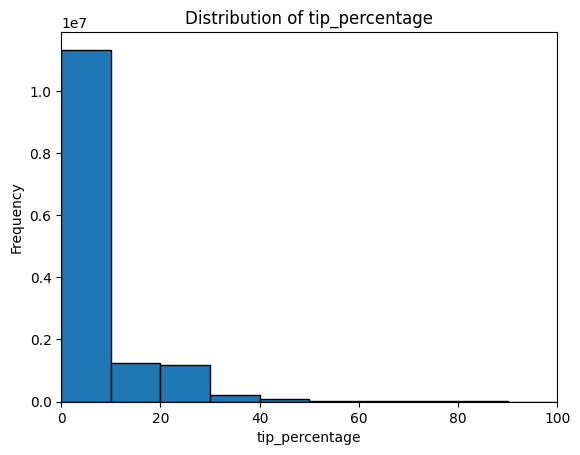

In [22]:
values = data_jan_2009["tip_percentage"].to_numpy()

plt.hist(values, bins=400, edgecolor='black')
plt.xlabel("tip_percentage")
plt.xlim(0, 100)
plt.ylabel("Frequency")
plt.title("Distribution of tip_percentage")
plt.show()

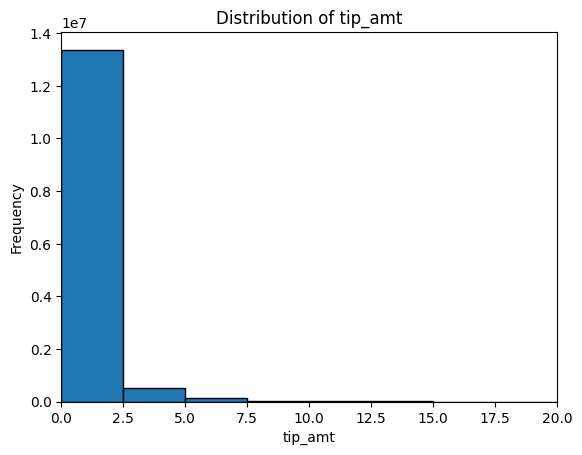

In [23]:
values = data_jan_2009["tip_amt"].to_numpy()

plt.hist(values, bins=40, edgecolor='black')
plt.xlabel("tip_amt")
plt.xlim(0, 20)
plt.ylabel("Frequency")
plt.title("Distribution of tip_amt")
plt.show()

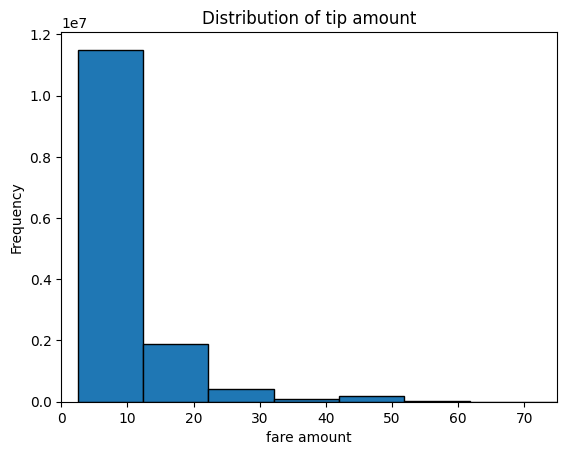

In [24]:
values = data_jan_2009["fare_amt"].to_numpy()

plt.hist(values, bins=20, edgecolor='black')
plt.xlim(0, 75)
plt.xlabel("fare amount")
plt.ylabel("Frequency")
plt.title("Distribution of tip amount")
plt.show()

In [25]:
mean_tips = data_jan_2009["tip_percentage"].mean()
q1_tips = data_jan_2009["tip_percentage"].quantile(0.25)
q3_tips = data_jan_2009["tip_percentage"].quantile(0.75)

In [38]:
data_jan_2009 = data_jan_2009.with_columns(
    pl.when(pl.col("tip_percentage") == 0).then(0)
     .when(pl.col("tip_percentage") < 20).then(1)
     .otherwise(2)
     .alias("tip_category")
)


In [40]:
data_jan_2009 = data_jan_2009.drop(["tip_amt"])

In [22]:
data_jan_2009.head()

passenger_count,trip_distance,payment_type,fare_amt,duration_seconds,tip_category
i64,f64,i64,f64,i64,i32
1,2.63,1,8.9,600,1
3,4.55,0,12.1,420,3
5,10.35,0,23.7,840,3
1,5.0,0,14.9,1262,3
1,0.4,1,3.7,393,1


In [39]:
data_jan_2009["tip_category"].value_counts()

tip_category,count
i32,u32
0,11155831
2,1530890
1,1405637


# print(mean_tips)

In [25]:
print(q1_tips)

0.0


In [26]:
print(q3_tips)

0.0


In [41]:
data_jan_2009 = data_jan_2009.drop(["tip_percentage"])

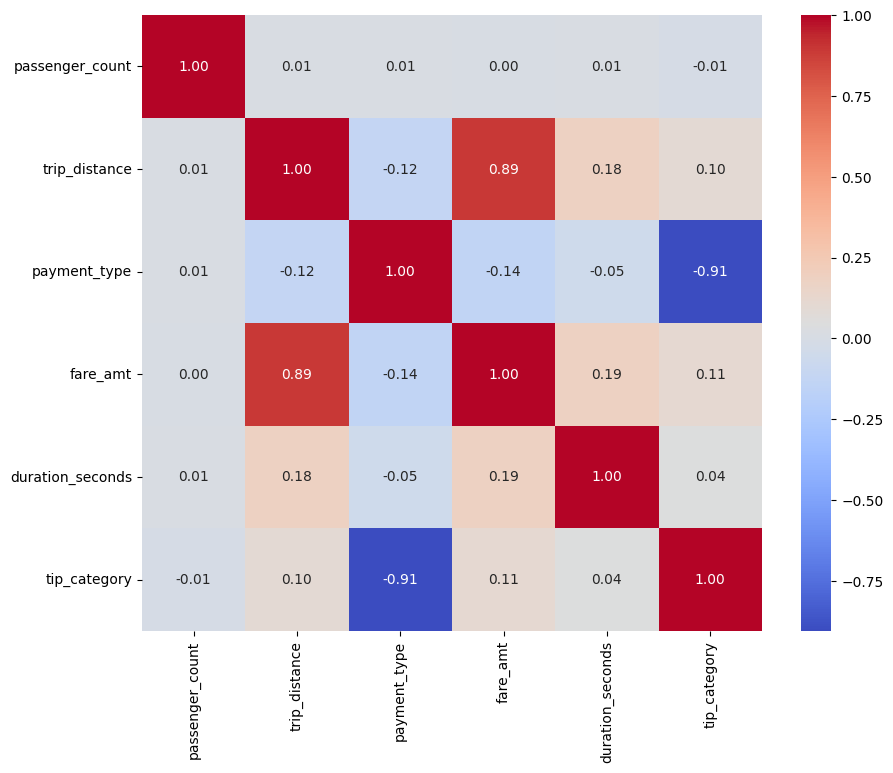

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = data_jan_2009.select(pl.all().cast(pl.Float64)).to_pandas().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [44]:
#y = data_jan_2009['tip_or_no']
#X = data_jan_2009.drop(['tip_or_no'])

y = data_jan_2009.select('tip_category').to_numpy().ravel().astype(int)
X = data_jan_2009.drop(['tip_category']).to_numpy()


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [36]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())
])

pipeline.fit(X_train, y_train)

,steps,"[('smote', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'


In [37]:
pipeline.score(X_test,y_test)

0.9931814117720523

Accuracy: 0.9931643093370179
Confusion Matrix:
 [[11063772    92059]
 [    4272  2932255]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00  11155831
           1       0.97      1.00      0.98   2936527

    accuracy                           0.99  14092358
   macro avg       0.98      1.00      0.99  14092358
weighted avg       0.99      0.99      0.99  14092358

ROC AUC: 0.9958318103698416


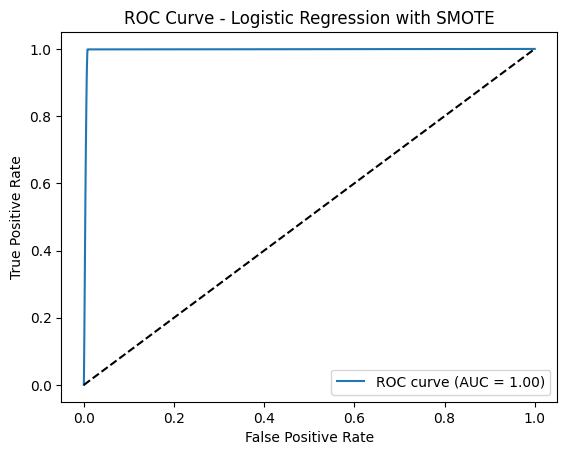

In [39]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# --- 1. Example data (replace with your own X, y)
#X, y = make_classification(
#    n_samples=2000, n_features=10, n_informative=5, n_redundant=2,
#    weights=[0.9, 0.1], random_state=42
#)

# --- 2. Build pipeline: SMOTE -> Scaling -> Logistic Regression
model = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='liblinear', random_state=42))
])

# --- 3. Cross-validation (Stratified K-Fold preserves class balance)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use cross_val_predict to get out-of-fold predictions
y_pred = cross_val_predict(model, X, y, cv=cv, method='predict')
y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

# --- 4. Metrics
acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)
roc_auc = roc_auc_score(y, y_proba)

print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y, y_pred))
print("ROC AUC:", roc_auc)

# --- 5. ROC curve plot
fpr, tpr, thresholds = roc_curve(y, y_proba)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression with SMOTE')
plt.legend()
plt.show()

CV Accuracy: 0.6648014712939265
Confusion Matrix (CV):
[[6521613 2403051]
 [1375939  973283]]
AUC (CV): 0.6110430074745824
Test Accuracy: 0.6652225035409257
Confusion Matrix (Test):
[[1631520  599647]
 [ 343914  243391]]
AUC (Test): 0.6117767017328857


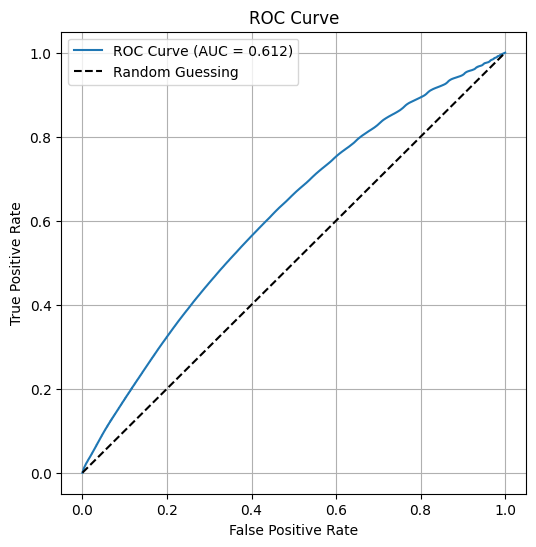

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# =======================
# 1. Prepare data
# =======================
# X: features (numpy array or pandas DataFrame)
# y: labels (numpy array or pandas Series)
# Example:
# X, y = ...
# Ensure y is numeric (0/1), not strings

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =======================
# 2. Define pipeline
# =======================
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='lbfgs', max_iter=1000))
])

# =======================
# 3. Cross-validation (StratifiedKFold)
# =======================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(pipeline, X_train, y_train, cv=cv, method='predict')
y_prob_cv = cross_val_predict(pipeline, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

print("CV Accuracy:", accuracy_score(y_train, y_pred_cv))
print("Confusion Matrix (CV):")
print(confusion_matrix(y_train, y_pred_cv))
print("AUC (CV):", roc_auc_score(y_train, y_prob_cv))

# =======================
# 4. Fit final model on full training set
# =======================
pipeline.fit(X_train, y_train)
y_pred_test = pipeline.predict(X_test)
y_prob_test = pipeline.predict_proba(X_test)[:, 1]

# =======================
# 5. Evaluate on test set
# =======================
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test))
print("AUC (Test):", roc_auc_score(y_test, y_prob_test))

# =======================
# 6. Plot ROC curve
# =======================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob_test):.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import gc
import matplotlib.pyplot as plt

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.base import clone
from joblib import parallel_backend

# ---- 1. Helper to force float32 (saves ~50% memory)
def to_float32(X):
    return np.asarray(X, dtype=np.float32)
float32_transformer = FunctionTransformer(to_float32, validate=False)

# ---- 2. Build the pipeline (SMOTE → scaling → RandomForest)
def build_pipeline():
    smote = SMOTE(sampling_strategy='auto', random_state=42)
    scaler = StandardScaler(with_mean=True, with_std=True)
    rf = RandomForestClassifier(
        n_estimators=50,    # fewer trees → less memory
        max_depth=12,       # limit depth
        max_samples=0.6,    # subsample each tree
        n_jobs=1,           # single-thread to avoid memory blowup during CV
        random_state=42,
        verbose=0
    )

    pipe = Pipeline([
        ('to_float32', float32_transformer),  # downcast first
        ('smote', smote),
        ('scaler', scaler),
        ('clf', rf)
    ])
    return pipe

# ---- 3. Manual CV with ROC evaluation (works with DataFrame or ndarray)
def cv_roc_oof(X, y, pipeline, n_splits=3, random_state=42, plot_roc=True):
    X = np.asarray(X)  # ensure ndarray indexing works
    y = np.asarray(y)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_probs = np.zeros(len(y), dtype=np.float32)

    fold = 0
    with parallel_backend('threading'):
        for train_idx, test_idx in skf.split(X, y):
            fold += 1
            print(f"[CV] Fold {fold}/{n_splits} — train {len(train_idx)}, test {len(test_idx)}")

            X_train, X_test = X[train_idx], X[test_idx]
            y_train = y[train_idx]

            est = clone(pipeline)
            est.fit(X_train, y_train)   # SMOTE happens here only on train fold

            probs = est.predict_proba(X_test)[:, 1].astype(np.float32)
            oof_probs[test_idx] = probs

            del est, X_train, X_test, y_train, probs
            gc.collect()

    roc_auc = roc_auc_score(y, oof_probs)
    fpr, tpr, thresholds = roc_curve(y, oof_probs, pos_label=1)
    print(f"[CV] Out-of-fold ROC AUC: {roc_auc:.4f}")

    if plot_roc:
        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, label=f'OOF ROC (AUC = {roc_auc:.4f})')
        plt.plot([0,1],[0,1],'--', alpha=0.5)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Out-of-Fold ROC')
        plt.legend()
        plt.grid(True)
        plt.show()

    return oof_probs, roc_auc, (fpr, tpr, thresholds)

# ---- 4. Run it (X and y must already be ready)
pipeline = build_pipeline()
oof_probs, auc_val, roc_data = cv_roc_oof(X, y, pipeline, n_splits=3)


[CV] Fold 1/3 — train 9394905, test 4697453


In [30]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import numpy as np

# Example dataset
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2,
                           weights=[0.9, 0.1], random_state=42)

# Split into train/test before applying SMOTE (apply only on train!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Original dataset shape:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Resampled dataset shape:", dict(zip(*np.unique(y_resampled, return_counts=True))))


Original dataset shape: {np.int64(0): np.int64(628), np.int64(1): np.int64(72)}
Resampled dataset shape: {np.int64(0): np.int64(628), np.int64(1): np.int64(628)}
